# Autoencoder Model Architecture Analysis

This notebook analyzes and compares the different autoencoder model architectures used in the project.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from models.autoencoder.model_variants import get_model_variant
import pandas as pd
from torchsummary import summary
import time
import os
import sys

## Define Model Variants

In [2]:
# Model variants to analyze
model_variants = ["direct", "light", "grouped", "efficient", "optimized", "grouped_latent"]

## Helper Functions for Model Analysis

In [3]:
def count_parameters(model):
    """Count the number of trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_time(model, input_shape=(1, 1, 64, 128, 128), num_iterations=100):
    """Measure the inference time of a model"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Create dummy input
    dummy_input = torch.randn(input_shape).to(device)
    
    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)
    
    # Measure time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / num_iterations
    return avg_time * 1000  # Convert to milliseconds

def measure_memory_usage(model, input_shape=(1, 1, 64, 128, 128)):
    """Estimate the memory usage of a model during forward pass"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    # Create dummy input
    dummy_input = torch.randn(input_shape).to(device)
    
    # Clear cache if using CUDA
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    
    # Forward pass
    with torch.no_grad():
        _ = model(dummy_input)
    
    # Get memory usage
    if device.type == "cuda":
        memory_usage = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
    else:
        # For CPU, we can only estimate based on model parameters
        memory_usage = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)  # MB
    
    return memory_usage

def analyze_model(variant_name):
    """Analyze a specific model variant"""
    try:
        # Create model instance
        model = get_model_variant(variant_name)
        
        # Count parameters
        num_params = count_parameters(model)
        
        # Measure inference time
        inference_time = measure_inference_time(model)
        
        # Measure memory usage
        memory_usage = measure_memory_usage(model)
        
        return {
            "variant": variant_name,
            "parameters": num_params,
            "inference_time_ms": inference_time,
            "memory_usage_mb": memory_usage
        }
    except Exception as e:
        print(f"Error analyzing {variant_name} model: {str(e)}")
        return None

## Analyze Each Model

In [4]:
# Analyze each model
model_stats = []
for variant in model_variants:
    try:
        stats = analyze_model(variant)
        model_stats.append(stats)
        print(f"Analyzed {variant} model")
    except Exception as e:
        print(f"Error analyzing {variant} model: {str(e)}")

Analyzed direct model
Analyzed light model
Analyzed grouped model
Analyzed efficient model
Analyzed optimized model
Analyzed grouped_latent model


## Display Model Summaries

In [5]:
# Display model summaries
for variant in model_variants:
    print(f"\n{'='*80}")
    print(f"Model: {variant}")
    print(f"{'='*80}")
    
    try:
        model = get_model_variant(variant)
        model.eval()
        
        # Move to CPU for visualization
        device = torch.device("cpu")
        model = model.to(device)
        
        # Print model summary for 3D input (1, 64, 128, 128)
        summary(model, input_size=(1, 64, 128, 128), device="cpu")
    except Exception as e:
        print(f"Error displaying summary for {variant} model: {str(e)}")


Model: direct
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1     [-1, 16, 64, 128, 128]             448
       BatchNorm3d-2     [-1, 16, 64, 128, 128]              32
              ReLU-3     [-1, 16, 64, 128, 128]               0
         ConvBlock-4     [-1, 16, 64, 128, 128]               0
            Conv3d-5       [-1, 32, 32, 64, 64]          13,856
       BatchNorm3d-6       [-1, 32, 32, 64, 64]              64
              ReLU-7       [-1, 32, 32, 64, 64]               0
         ConvBlock-8       [-1, 32, 32, 64, 64]               0
            Conv3d-9       [-1, 32, 32, 64, 64]          27,680
      BatchNorm3d-10       [-1, 32, 32, 64, 64]              64
             ReLU-11       [-1, 32, 32, 64, 64]               0
        ConvBlock-12       [-1, 32, 32, 64, 64]               0
           Conv3d-13       [-1, 64, 16, 32, 32]          55,360
      BatchNorm3d-14    

## Compare Model Statistics

In [6]:
# Create DataFrame for comparison
stats_df = pd.DataFrame(model_stats)
stats_df

,variant,parameters,inference_time_ms,memory_usage_mb
0,direct,5292497,1019.970813,20.189274
1,light,1324329,601.515350,5.051914
2,grouped,1326737,2340.635107,5.061100
3,efficient,243857,1408.774214,0.930241
4,optimized,227763,336.174800,0.868847
5,grouped_latent,177465,195.702815,0.676975


## Visualize Parameter Count Comparison

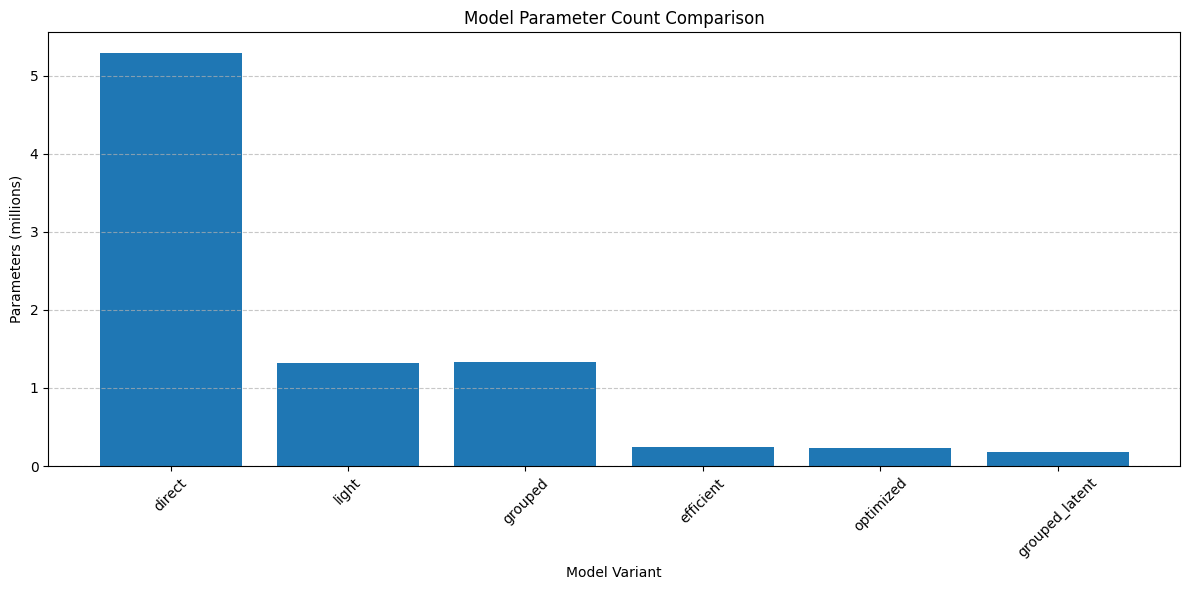

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(stats_df['variant'], stats_df['parameters'] / 1e6)
plt.title('Model Parameter Count Comparison')
plt.xlabel('Model Variant')
plt.ylabel('Parameters (millions)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualize Inference Time Comparison

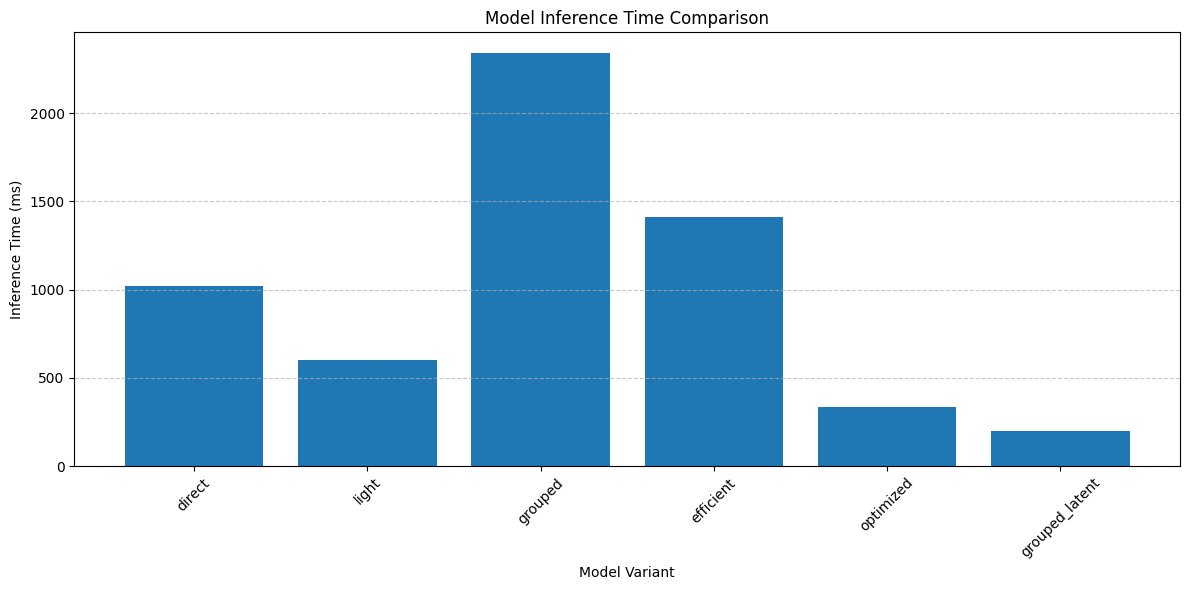

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(stats_df['variant'], stats_df['inference_time_ms'])
plt.title('Model Inference Time Comparison')
plt.xlabel('Model Variant')
plt.ylabel('Inference Time (ms)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualize Memory Usage Comparison

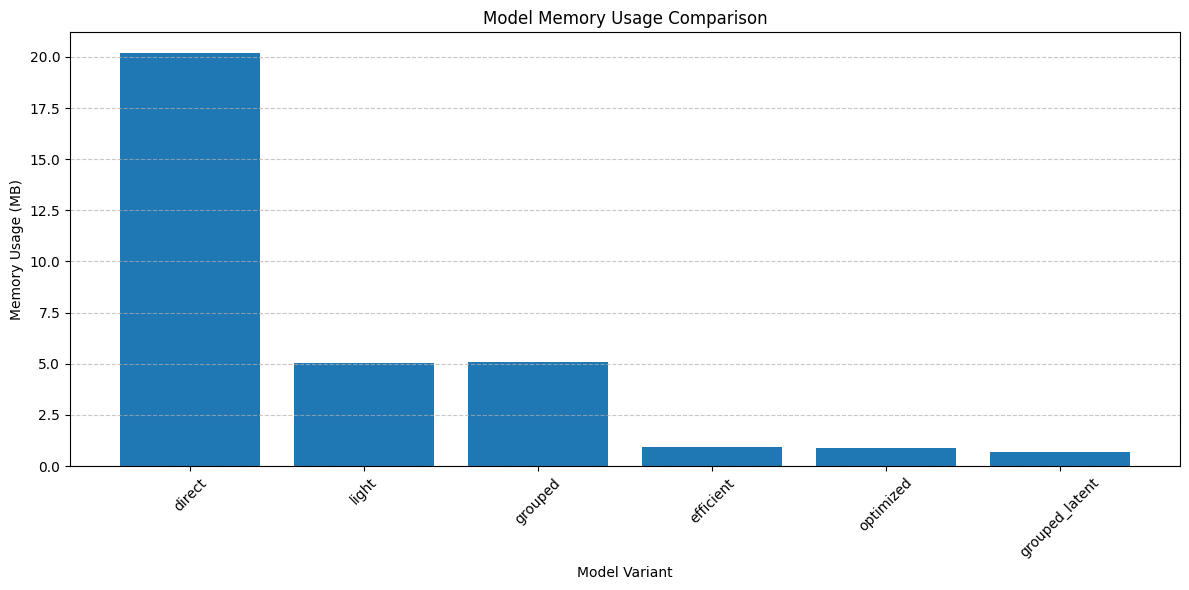

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(stats_df['variant'], stats_df['memory_usage_mb'])
plt.title('Model Memory Usage Comparison')
plt.xlabel('Model Variant')
plt.ylabel('Memory Usage (MB)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Normalized Comparison (Relative to Direct Model)

In [10]:
# Create normalized DataFrame
direct_stats = stats_df[stats_df['variant'] == 'direct'].iloc[0]
normalized_df = stats_df.copy()

for col in ['parameters', 'inference_time_ms', 'memory_usage_mb']:
    normalized_df[f'normalized_{col}'] = normalized_df[col] / direct_stats[col]

normalized_df

,variant,parameters,inference_time_ms,memory_usage_mb,normalized_parameters,normalized_inference_time_ms,normalized_memory_usage_mb
0,direct,5292497,1019.970813,20.189274,1.000000,1.000000,1.000000
1,light,1324329,601.515350,5.051914,0.250228,0.589738,0.250228
2,grouped,1326737,2340.635107,5.061100,0.250683,2.294806,0.250683
3,efficient,243857,1408.774214,0.930241,0.046076,1.381191,0.046076
4,optimized,227763,336.174800,0.868847,0.043035,0.329593,0.043035
5,grouped_latent,177465,195.702815,0.676975,0.033531,0.191871,0.033531


## Visualize Normalized Comparison

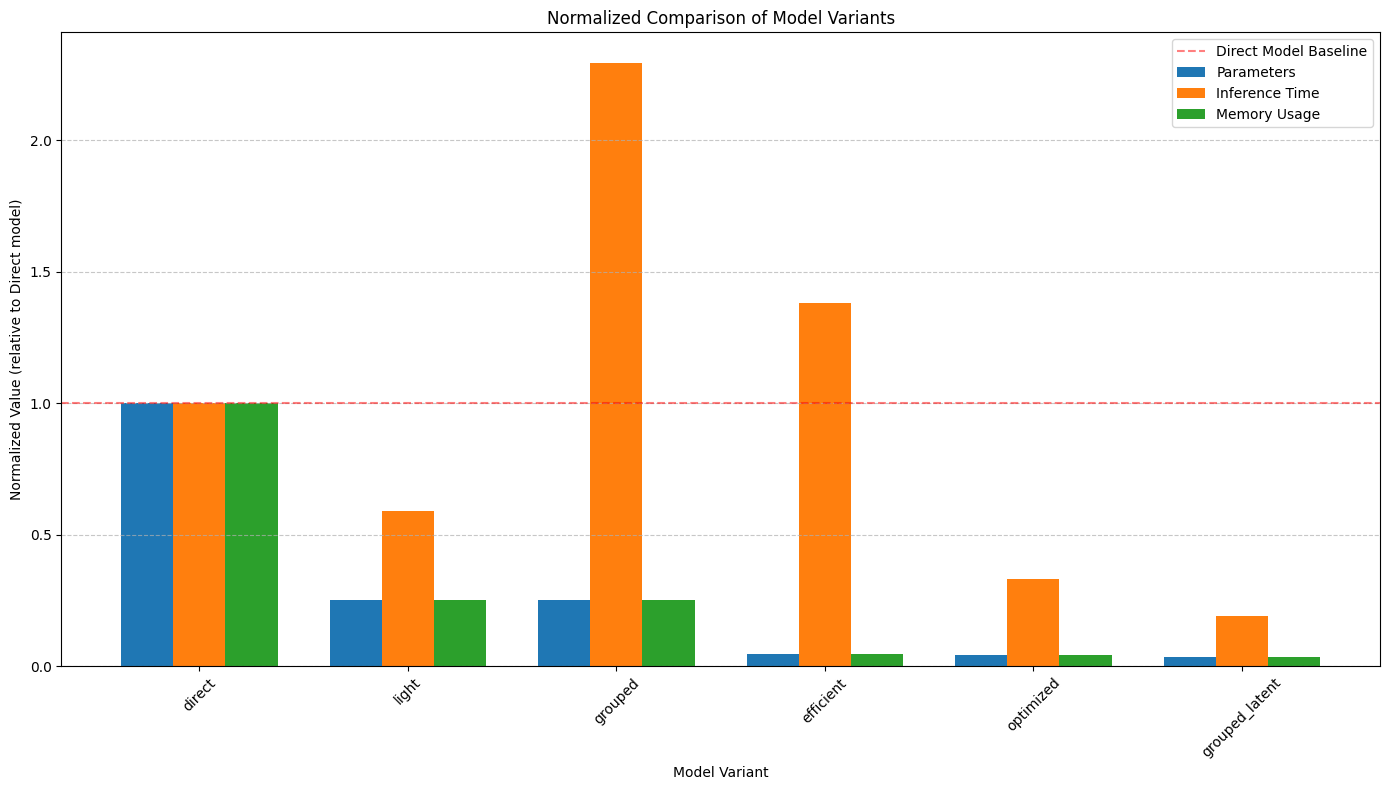

In [11]:
metrics = ['normalized_parameters', 'normalized_inference_time_ms', 'normalized_memory_usage_mb']
labels = ['Parameters', 'Inference Time', 'Memory Usage']

plt.figure(figsize=(14, 8))

x = np.arange(len(normalized_df['variant']))
width = 0.25

for i, (metric, label) in enumerate(zip(metrics, labels)):
    plt.bar(x + i*width - width, normalized_df[metric], width, label=label)

plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Direct Model Baseline')
plt.xlabel('Model Variant')
plt.ylabel('Normalized Value (relative to Direct model)')
plt.title('Normalized Comparison of Model Variants')
plt.xticks(x, normalized_df['variant'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Efficiency Score (Lower is Better)

In [12]:
# Calculate efficiency score (weighted average of normalized metrics)
weights = {'parameters': 0.4, 'inference_time_ms': 0.3, 'memory_usage_mb': 0.3}
efficiency_df = normalized_df.copy()

efficiency_df['efficiency_score'] = (
    weights['parameters'] * efficiency_df['normalized_parameters'] +
    weights['inference_time_ms'] * efficiency_df['normalized_inference_time_ms'] +
    weights['memory_usage_mb'] * efficiency_df['normalized_memory_usage_mb']
)

# Sort by efficiency score (lower is better)
efficiency_df = efficiency_df.sort_values('efficiency_score')
efficiency_df

,variant,parameters,inference_time_ms,memory_usage_mb,normalized_parameters,normalized_inference_time_ms,normalized_memory_usage_mb,efficiency_score
5,grouped_latent,177465,195.702815,0.676975,0.033531,0.191871,0.033531,0.081033
4,optimized,227763,336.174800,0.868847,0.043035,0.329593,0.043035,0.129002
1,light,1324329,601.515350,5.051914,0.250228,0.589738,0.250228,0.352081
3,efficient,243857,1408.774214,0.930241,0.046076,1.381191,0.046076,0.446610
2,grouped,1326737,2340.635107,5.061100,0.250683,2.294806,0.250683,0.863920
0,direct,5292497,1019.970813,20.189274,1.000000,1.000000,1.000000,1.000000


## Visualize Efficiency Score

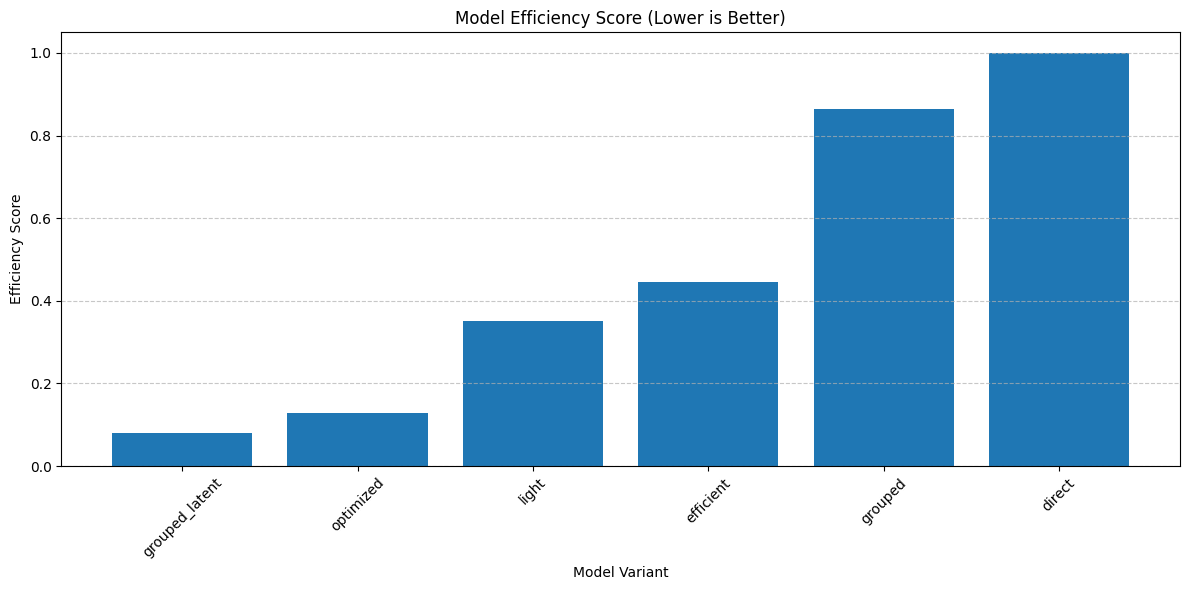

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(efficiency_df['variant'], efficiency_df['efficiency_score'])
plt.title('Model Efficiency Score (Lower is Better)')
plt.xlabel('Model Variant')
plt.ylabel('Efficiency Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

This analysis compares the different autoencoder model architectures in terms of parameter count, inference time, and memory usage. The efficiency score provides a weighted measure of overall model efficiency, with lower scores indicating better efficiency.

Based on the results, we can rank the models from most efficient to least efficient and make recommendations for different use cases.